## Why do animals increase persistence with rewards?

Here, I consider environments with two properties:
1. Rewards in patches deplete stochastically, and their depletion is not signalled to the agent.
2. Rewards curves a drawn from a distribution, and there is no odor to distinguish them.

Each patch's reward curve is parameterized via a tuple, $(a, s)$. Rewards from the patch are dictated by Markov process which has two states, ON and OFF.

If ON, the patch emits rewards with probability $a$. After reward is attempted, it transitions with probability $s$ back to ON. With probability $1-s$, it transitions to OFF. If OFF, the patch no longer emits rewards and remains in OFF forever.

### Single patch case
We first calculate the probability of reward given a reward history, $\{r\}$, when the environment only has a single patch with known $(s, a)$.

$$
\begin{aligned}
    p(r=1 | \{r\}) &= p(r=1 | \rm{ON}) p(\rm{ON} | \{r\}) \\
                   &= p(r=1 | \rm{ON}) \frac{p(\rm{ON}, \{r\})}{p(\{r\})} \\
                   &= a \frac{p(\rm{ON}, \{r\})}{p(\{r\})}
\end{aligned}
$$

The state can only be ON if the patch has survived for the duration of the reward history and the emissions match the observed emmisions. This is

$$
\begin{aligned}
    p(\rm{ON}, \{r\}) = s^l a^{n} (1-a)^{l - n},
\end{aligned}
$$
where $l = |\{r\}|$ and $n$ is the number of rewards obtained.

$p(\{r\})$ considers all the competing hypotheses that explain the reward history. These hypotheses include the hypothesis that the patch has not transitioned, but also the possibilities that the patch has transitioned after the last observed reward. This can be written as

$$
\begin{aligned}
    p(\{r\}) &= p(\rm{ON}, \{r\}) + p(\rm{OFF}, \{r\}) \\
             &= s^l a^{n} (1-a)^{l - n} + s^{l-m} a^{n} (1-a)^{l - m - n} \sum_{m'=0}^{m-1} ((1-a)s)^{m'} (1-s),
\end{aligned}
$$
where the sum is over the exact step the patch died. $m$ here is the number of steps the reward has been 0 at the end of $\{r\}$. This yields

$$
\begin{aligned}
    p(\rm{ON} | \{r\}) = \frac{((1-a)s)^m}{((1-a)s)^m + (1-s)\sum_{m'=0}^{m-1} ((1-a)s)^{m'}}
\end{aligned}
$$

The probability of reward is simply $a$ multiplied by this quantity. Notice there is no reference to the reward history in this quantity except through $m$, thus $m$ is a sufficient statistic for computing the probability of reward in this environment.


### Numerical experiments in single patch environment

In [154]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random

import os, sys
sys.path.insert(0, os.path.abspath('../..'))
sys.path.insert(0, os.path.abspath('..'))   # code/ dir (aux_funcs)
from aux_funcs import format_plot

In [155]:
def prob_alive_since_last_reward(fails_since_last_reward, a, s):
    not_a = 1. - a
    return (1 - s) * np.sum([
        (not_a * s) ** (fails_since_last_reward - n) * a**n
        for n in range(fails_since_last_reward)

    ]) + (not_a * s) ** fails_since_last_reward

def alive_given_reward_history(r, s, a):
    reward_indices = np.where(r==1)[0]
    if len(reward_indices) == 0:
        fails_since_last_reward = len(r)
    else:
        fails_since_last_reward = len(r) - reward_indices[-1] - 1
    not_a = 1. - a
    denom = prob_alive_since_last_reward(fails_since_last_reward, a, s)
    return (not_a * s) ** fails_since_last_reward / denom

We can plot the probability the patch is alive as a function of the time since the last reward was observed given different values of $s$.

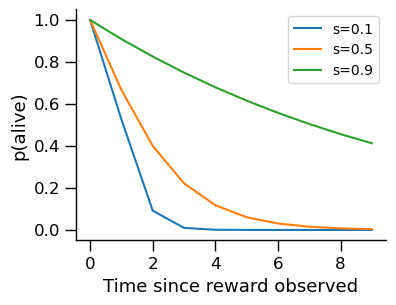

In [159]:
fig, axs = plt.subplots(1, 1, figsize=(4, 3))
base = np.zeros(10).astype(int)

for s in [0.1, 0.5, 0.9]:
    arr = []
    for i in range(10):
        reward_history = np.copy(base)
        reward_history[i] = 1
        arr.append(alive_given_reward_history(reward_history, s, 0.5))
    axs.plot(9 - np.arange(10), arr, label=f's={s}')

axs.set_ylim(-0.05, 1.05)
axs.set_ylabel('p(alive)')
axs.set_xlabel('Time since reward observed')
axs.legend()
format_plot(axs)

### Summary heatmaps for single patch case
Since $m$ is a sufficient statistic on the reward probability given a reward history, we know plots of reward probability in the space of accumulated reward vs consecutive failures ($m$) will be invariant along the accumulated reward direction.

Below I search over all reward histories up to length 15 using the following strategy. Begin by considering [0] and [1]. For each, if the probability of reward exceeds some value $g$, consider the successors of these states, e.g. for [0], the successors are [0, 1], [0, 0]. Continue until termintation.

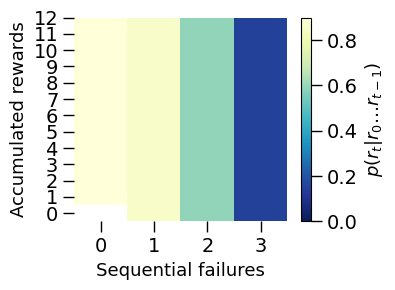

In [ ]:
s_param, a_param = 0.95, 0.9
g = 0.2
max_depth = 15

explored = {}
frontier = [[0], [1]]
while frontier:
    seq = frontier.pop()
    m = alive_given_reward_history(np.array(seq, dtype=int), s_param, a_param) * a_param
    explored[tuple(seq)] = m
    if m > g and len(seq) < max_depth:
        frontier.append(seq + [0])
        frontier.append(seq + [1])

# (trailing zeros x sum) heatmap of (marginal - g) over the explored sequences
recs = []
for seq, m in explored.items():
    tz = 0
    for v in reversed(seq):
        if v == 0:
            tz += 1
        else:
            break
    recs.append((tz, int(sum(seq)), m))

recs = np.array(recs, dtype=float)
tz_max = int(recs[:, 0].max())
sum_max = int(recs[:, 1].max())

grid = np.zeros((sum_max + 1, tz_max + 1))
counts = np.zeros_like(grid)
for tz, ssum, val in recs:
    grid[int(ssum), int(tz)] += val
    counts[int(ssum), int(tz)] += 1
grid = np.where(counts > 0, grid / np.where(counts == 0, 1, counts), np.nan)

vmax = np.nanmax(np.abs(grid))
fig, ax = plt.subplots(figsize=(4, 3))
im = ax.imshow(grid, origin='lower', aspect='auto', cmap='YlGnBu_r',
               vmin=0, vmax=vmax)
ax.set_xlabel('Sequential failures')
ax.set_ylabel('Accumulated rewards')
ax.set_xticks(range(tz_max + 1))
ax.set_yticks(range(sum_max + 1))
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r'$p(r_t|{r_0 \ldots r_{t-1})}$')
format_plot(ax, bottomspine=False, leftspine=False, ticklabelsize=14)
format_plot(cbar.ax, bottomspine=False, leftspine=False, ticklabelsize=14)
ax.set_ylim(-0.5, 12)
fig.tight_layout()
plt.show()


### Multipatch case
Now we assume a prior over the possible values of $a$ and $s$. Specifically I assume a uniform prior, but this could probably be amended.

To calculate $p(r=1|\{r\})$, we now need to integrate over the possible values of $a, s$ given the prior.

$$
\begin{aligned}
    p(r=1 | \{r\}) &= \iint_{a,\, s} p(r=1 | a, s, \{r\}) p(a, s | \{r\})
\end{aligned}
$$

For the second term, we have
$$
\begin{aligned}
    p(a, s | \{r\}) = \frac{p(\{r\}|a,s)}{p(\{r\})} p(a, s)
\end{aligned}
$$

Assuming the prior is uniform, we get

$$
\begin{aligned}
    p(a, s | \{r\}) \sim \frac{p(\{r\}|a,s)}{p(\{r\})}.
\end{aligned}
$$

Together this gives

$$
\begin{aligned}
    p(r=1 | \{r\}) &= \iint_{a,\, s} p(r=1 | a, s, \{r\}) \frac{p(\{r\}|a,s)}{p(\{r\})}
\end{aligned}
$$

The first term in the integral is exactly the main result of the first section. We have also computed the second term in the numerator previously. Above, we had derived it as $p(\{r\})$, but here we identify it as $p(\{r\}|a, s)$.



$$
\begin{aligned}
    p(\{r\}|a, s)  &= s^l a^{n} (1-a)^{l - n} + s^{l-m} a^{n} (1-a)^{l - m - n} \sum_{m'=0}^{m-1} ((1-a)s)^{m'} (1-s)
\end{aligned}
$$

This is exactly $s^{l-m} (1-a)^{l-m-n} a^n$ multiplied by the denominator of $p(r=1 | a, s, \{r\})$. Therefore,

$$
\begin{aligned}
    p(r=1 | a, s, \{r\}) p(\{r\}|a,s) &= a((1-a)s)^m s^{l-m} (1-a)^{l-m-n} a^n \\
                                      &= s^{l} (1-a)^{l-n} a^{n+1}
\end{aligned}
$$

We can compute the denominator by marginalizing $p(\{r\}|a, s)$ over the priors of $a$ and $s$, which here we just take to be uniform.

In [160]:
# numerator of p(r_t | r_0 ... r_{t-1})
def prob_reward_given_history(r, s, a):
    return s**len(r) * a ** (np.sum(r) + 1) * (1-a) ** (len(r) - np.sum(r))

# denominator of p(r_t | r_0 ... r_{t-1}) before integrating over s and a
def p_history_given_params(r, s, a):
    reward_indices = np.where(r==1)[0]
    if len(reward_indices) == 0:
        fails_since_last_reward = len(r)
    else:
        fails_since_last_reward = len(r) - reward_indices[-1] - 1
    return (s**(len(r) - fails_since_last_reward)
            * a**(np.sum(r))
            * (1-a)**(len(r) - fails_since_last_reward - np.sum(r))
            * prob_alive_since_last_reward(fails_since_last_reward, a, s)
    )

# full probability of reward given history, integrating over s and a
def prob(r, s_list, a_list):
    numerator = np.sum([
        prob_reward_given_history(r, s, a) for s, a in zip(s_list, a_list)
    ]) 
    denom = np.sum([
        p_history_given_params(r, s, a) for s, a in zip(s_list, a_list)
    ]) 
    return numerator / denom

I use the same strategy as before to find viable reward histories given an MVT-like policy.

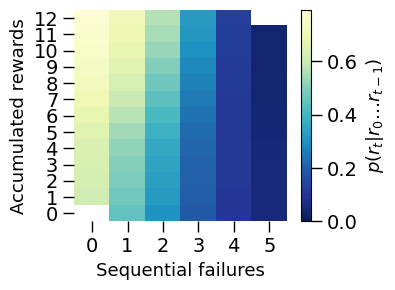

In [151]:
# First heatmap, but sampling sequences via the iterative branching process and
# plotting (marginal - g). Branch on marginal(r, s, a) > g, expanding both
# successors (append 0 / append 1) until marginal <= g or max_depth is reached.

s_list = np.linspace(0.5, 0.95, 10).tolist()
a_list = np.linspace(0.4, 0.8, 10).tolist()
g = 0.1
max_depth = 16

explored = {}     # tuple(seq) -> marginal
frontier = [[0], [1]]
while frontier:
    seq = frontier.pop()
    m = prob(np.array(seq, dtype=int), s_list, a_list)
    explored[tuple(seq)] = m
    if m > g and len(seq) < max_depth:
        frontier.append(seq + [0])
        frontier.append(seq + [1])

recs = []
for seq, m in explored.items():
    tz = 0
    for v in reversed(seq):
        if v == 0:
            tz += 1
        else:
            break
    recs.append((tz, int(sum(seq)), m))

recs = np.array(recs, dtype=float)
tz_max = int(recs[:, 0].max())
sum_max = int(recs[:, 1].max())

grid = np.zeros((sum_max + 1, tz_max + 1))
counts = np.zeros_like(grid)
for tz, ssum, val in recs:
    grid[int(ssum), int(tz)] += val
    counts[int(ssum), int(tz)] += 1
grid = np.where(counts > 0, grid / np.where(counts == 0, 1, counts), np.nan)

vmax = np.nanmax(np.abs(grid))
fig, ax = plt.subplots(figsize=(4, 3))
im = ax.imshow(grid, origin='lower', aspect='auto', cmap='YlGnBu_r',
               vmin=0, vmax=vmax)
ax.set_xlabel('Sequential failures')
ax.set_ylabel('Accumulated rewards')
ax.set_xticks(range(tz_max + 1))
ax.set_yticks(range(sum_max + 1))
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r'$p(r_t|{r_0 \ldots r_{t-1})}$')
format_plot(ax, bottomspine=False, leftspine=False, ticklabelsize=14)
format_plot(cbar.ax, bottomspine=False, leftspine=False, ticklabelsize=14)
ax.set_ylim(-0.5, 12.5)
fig.tight_layout()
plt.show()